In [1]:
# ── GLOBAL CONFIG ─────────────────────────────────────────────────────────
USE_MOCK = True   # Set False to use real OpenAI client

In [2]:
# ╔══════════════════════════════════════════════════════════════════════════╗
# ║   demo_automated_pipeline.ipynb  —  4-Agent AML Escalation System        ║
# ║   Triage → Risk Analyst → Structuring Expert → Compliance Officer        ║
# ║                                                                          ║
# ║   All outputs → starter/outputs/                                         ║
# ║   Dashboard   → cd starter && streamlit run app.py                       ║
# ╚══════════════════════════════════════════════════════════════════════════╝

# 4-Agent AML Escalation System

## System Overview
The `demo_automated_pipeline.ipynb` orchestrates a sophisticated multi-agent investigation workflow designed for regulatory AML compliance.

### Workflow Pipeline
Triage ➔ Risk Analyst ➔ Structuring Expert ➔ Compliance Officer

---

### Project Directories
* **Outputs:** `starter/outputs/` 
  * *Contains all generated investigation artifacts and SAR documents.*

### Launching the Dashboard
To visualize the agent decision outputs, navigate to the project root and execute:

```bash
`cd starter && streamlit run app.py`

In [3]:
import subprocess, sys
subprocess.run([sys.executable, "-m", "pip", "install", "-r", "../requirements.txt", "-q"], check=True)

print("*"*80)
print("✅ Installing and Updating Dependencies")
subprocess.run([sys.executable, "-m", "pip", "install", "--upgrade", "pip"], check=True)
print("*"*80)
print("\n\n")
print("*"*80)
print("✅ Dependencies are updated and ready to use")
print("*"*80)


[notice] A new release of pip is available: 24.2 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


********************************************************************************
✅ Installing and Updating Dependencies
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 34.2 MB/s eta 0:00:00
  Attempting uninstall: pip
    Found existing installation: pip 24.2
    Uninstalling pip-24.2:
      Successfully uninstalled pip-24.2
********************************************************************************



********************************************************************************
✅ Dependencies are updated and ready to use
********************************************************************************


In [4]:
# ── CELL 1 — Environment Setup ────────────────────────────────────────────
import os
import sys
import json
import uuid
import pandas as pd
from datetime import datetime
from dotenv import load_dotenv
 
# Add starter/src/ to path (notebook lives in starter/notebooks/)
sys.path.append(os.path.abspath('../src'))
load_dotenv('../.env')
 
from foundation_sar import DataLoader, ExplainabilityLogger, load_csv_data
 
print("📚 Libraries imported successfully!")
print("🔐 Environment variables loaded")
print("📂 Source directory added to Python path")
 

📚 Libraries imported successfully!
🔐 Environment variables loaded
📂 Source directory added to Python path


In [5]:
# ── CELL 2 — OpenAI Client ───────────────────────────────────────────────
import openai
 
openai_api_key = os.getenv('OPENAI_API_KEY')
 
if not openai_api_key:
    print("⚠️  WARNING: No OpenAI API key found — running in MOCK mode")
    client = None
else:
    client = openai.OpenAI(
        base_url="https://openai.vocareum.com/v1",
        api_key=openai_api_key,
    )
    print("✅ OpenAI client initialized with Vocareum routing")
    print(f"🔑 API key : {openai_api_key[:8]}...{openai_api_key[-4:]}")
    print("📍 Base URL: https://openai.vocareum.com/v1")
 

✅ OpenAI client initialized with Vocareum routing
🔑 API key : voc-1750...0392
📍 Base URL: https://openai.vocareum.com/v1


In [6]:
# ── CELL 3 — Logger + Model Tier Selection ───────────────────────────────
from IPython.display import clear_output, display
from config_manager import get_model_input
 
logger                = ExplainabilityLogger()
explainability_logger = ExplainabilityLogger("../outputs/audit_logs/demo_pipeline.jsonl")
 
clear_output()
selector, ui_display = get_model_input()
display(ui_display)

Output()

In [7]:
# ── CELL 4 — Agent & Orchestrator Init ───────────────────────────────────
from src.mock.mock_client import InternalMockClient
from structuring_expert import StructuringExpert
from triage_analyst_agent import TriageAgent
from risk_analyst_agent import RiskAnalystAgent
from compliance_officer_agent import ComplianceOfficerAgent
from src.orchestrator import FraudOrchestrator

if USE_MOCK:
    active_client = InternalMockClient()
    print("🧪 Running in MOCK mode")
else:
    if client is None:
        raise ValueError("❌ USE_MOCK is False but no OpenAI client found — check your API key in .env")
    active_client = client
    print("🌐 Running with real OpenAI client")

triage_agent     = TriageAgent(active_client, logger)
risk_agent       = RiskAnalystAgent(active_client, logger)
expert_agent     = StructuringExpert(active_client, logger)
compliance_agent = ComplianceOfficerAgent(active_client, logger)

orchestrator = FraudOrchestrator(
    logger       = logger,
    client       = active_client,
    use_mock     = USE_MOCK,
    triage       = triage_agent,
    risk_analyst = risk_agent,
    expert       = expert_agent,
    officer      = compliance_agent,
)

print("✅ Agents and Orchestrator initialized")
print(f"   USE_MOCK        : {USE_MOCK}")
print(f"   Client ID       : {id(active_client)}")
print(f"   Orchestrator ID : {id(orchestrator.client)}")
print(f"   Triage Agent ID : {id(triage_agent.client)}")

🧪 Running in MOCK mode
DEBUG [TriageAgent]: Received client ID 140494035659680
DEBUG [RiskAnalystAgent]: Received client ID 140494035659680
DEBUG [StructuringExpert]: Received client ID 140494035659680
DEBUG [ComplianceOfficerAgent]: Received client ID 140494035659680
DEBUG [Orchestrator]: Received client ID 140494035659680
DEBUG [Orchestrator]: Assigned self.client ID 140494035659680
✅ Agents and Orchestrator initialized
   USE_MOCK        : True
   Client ID       : 140494035659680
   Orchestrator ID : 140494035659680
   Triage Agent ID : 140494035659680


In [8]:
# ── CELL 5 — Data Loading ────────────────────────────────────────────────
from demo_integration_pipeline import load_and_preprocess_data
 
notebook_dir = os.getcwd()
data_dir     = os.path.abspath(os.path.join(notebook_dir, '..', 'data'))
print(f"📂 Loading data from: {data_dir}")
 
customers_data, accounts_data, transactions_data = load_and_preprocess_data(data_dir)
 

📂 Loading data from: /workspace/cd14685-fin-serv-agentic-c1-classroom/project/starter/data
📊 Loading Cleaned Financial Data
🧹 Stage 2: Cleaning missing values...
✅ Data cleaned.
🔄 Stage 3: Converting to dictionary format...
✅ Conversion complete.
📈 Loaded: 150 customers, 178 accounts, 4268 transactions


In [9]:
# ── CELL 6 — Customer Risk Screening ─────────────────────────────────────
from demo_integration_pipeline import screen_high_risk_customers
 
selected_customers, rest_of_cases = screen_high_risk_customers(
    customers_data, accounts_data, transactions_data
)
 
print(f"\n📊 Top high-risk cases : {len(selected_customers)}")
print(f"   Remaining cases     : {len(rest_of_cases)}")

🔍 Customer Risk Screening
🔍 Screening 150 customers for high-risk flags...
📊 Selected 9 top-risk customers
   Remaining flagged : 16

📊 Top high-risk cases : 9
   Remaining cases     : 16


In [10]:
# ── CELL 7 — Build CaseData Objects ──────────────────────────────────────
from demo_integration_pipeline import build_case_objects
 
data_loader     = DataLoader(explainability_logger)
 
high_risk_cases = build_case_objects(selected_customers, data_loader)
remaining_cases = build_case_objects(rest_of_cases,      data_loader)
 
print(f"\n✅ high_risk_cases : {len(high_risk_cases)}")
print(f"   remaining_cases  : {len(remaining_cases)}")

✅ Built 9 CaseData objects.
✅ Built 16 CaseData objects.

✅ high_risk_cases : 9
   remaining_cases  : 16


In [11]:
# ── CELL 8 — Run 4-Agent Pipeline ────────────────────────────────────────
from demo_integration_pipeline import run_agent_pipeline
 
# HIGH RISK batch
res1 = run_agent_pipeline(high_risk_cases, orchestrator, is_high_risk=True)
processed_cases_hr, approved_sars_hr, rejected_cases_hr, audit_decisions_hr, label_hr = res1
 
# REMAINING batch
res2 = run_agent_pipeline(remaining_cases, orchestrator, is_high_risk=False)
processed_cases_rm, approved_sars_rm, rejected_cases_rm, audit_decisions_rm, label_rm = res2
 
# Merge into a single set of tracking variables used by metrics + exports
processed_cases = processed_cases_hr + processed_cases_rm
approved_sars   = approved_sars_hr   + approved_sars_rm
rejected_cases  = rejected_cases_hr  + rejected_cases_rm
audit_decisions = audit_decisions_hr + audit_decisions_rm
 
print(f"\n📊 Combined totals — Processed: {len(processed_cases)} | "
      f"Approved: {len(approved_sars)} | Rejected: {len(rejected_cases)}")
 


  🚀 4-AGENT ESCALATION PIPELINE — HIGH RISK CASES

🔍 Case: 74972423-290e-4108-8310-4b0f934467b1 | Customer: Jacqueline Rodriguez
DEBUG [Triage]: status=COMPLETE
DEBUG [Expert]: status=COMPLETE
DEBUG [Compliance] keys received: ['case_id', 'customer', 'accounts', 'transactions', 'case_created_at', 'data_sources', 'risk_rating', '_customer_name', 'status', 'is_suspicious', 'primary_risk_category', 'thought_process', 'triage_summary', 'confidence_score', 'feedback_addressed', 'analysis_depth', 'pattern_found', 'layering_indicators', 'reasoning', 'recommended_sar_priority']
⚠️  [OFFLINE MODE] Dynamic fallback narrative generated for Unknown Subject | 0 txns | $0.00 | High risk
DEBUG [Compliance]: status=COMPLETE
✅ SAR saved: /workspace/cd14685-fin-serv-agentic-c1-classroom/project/starter/outputs/filed_sars/SAR_c3c928a4.json
   ✅ SAR filed | Other | 91% confidence

🔍 Case: af1644d2-d32a-4033-a3b0-7c9fc2e6ee7c | Customer: Michael Stanley
DEBUG [Triage]: status=COMPLETE
DEBUG [Expert]: stat

In [12]:
# ── CELL 9 — Workflow Metrics ─────────────────────────────────────────────
from demo_integration_pipeline import analyze_workflow_efficiency, validate_ai_decisions
 
analyze_workflow_efficiency(processed_cases, approved_sars, rejected_cases, audit_decisions)
validate_ai_decisions(audit_decisions)


      CORPORATE SAR WORKFLOW DASHBOARD
Throughput Metrics:
  Total Volume         : 25 cases
  SAR Filing Volume    : 25
  Cases Filtered Early : 0

Time Efficiency (vs Human Baseline ~30min/case):
  Avg AI Processing    : <1s per case (estimated)
  Time Saved           : ~99.9% faster than manual review

Financial Performance (vs Full Human Workflow):
  AI Pipeline Cost     : $137.50
  Human Equivalent     : $5875.00
  Cost Savings         : $5737.50
  ROI                  : 97.7% cost reduction

Operational KPIs:
  High Confidence Rate : 24.0% of cases >= 80% confidence
  Triage Filter Rate   : 0.0%
  Note: 0% filter = all cases flagged suspicious (conservative AI tuning)

-------     AI Decision Analytics     -------
Average AI Model Confidence : 81.12%
Confidence (Median)         : 78.00%
Manual Human Overrides      : 0 cases
---------------------------------------------


In [13]:
# ── CELL 10 — Batch Visualisation ────────────────────────────────────────
import yaml
from IPython.display import Image
from demo_integration_pipeline import WorkflowVisualizer
 
with open('../config/pipeline_config.yaml', 'r') as f:
    config = yaml.safe_load(f)
 
OUTPUT_DIR    = config['directories']['output_charts']
REVIEW_ALL    = True   # Set True to chart remaining_cases separately too
 
batches = [("Selected_Customers", selected_customers)]
if REVIEW_ALL:
    batches.append(("Remaining_Customers", rest_of_cases))
    print("🚀 Full-scale review mode: Enabled")
else:
    print("🛡️  Managed review mode: Top-N high-risk cases only")
 
reporter = WorkflowVisualizer(output_dir=OUTPUT_DIR)
 
for i, (name, customer_group) in enumerate(batches, start=1):
    print(f"\n--- Chart batch: {name} ({len(customer_group)} cases) ---")
    reporter.generate(approved_sars, rejected_cases, audit_decisions, batch_num=i)
 

🚀 Full-scale review mode: Enabled

--- Chart batch: Selected_Customers (9 cases) ---
✅ Charts saved to ../outputs/charts  [525910_*_batch1.png]

--- Chart batch: Remaining_Customers (16 cases) ---
✅ Charts saved to ../outputs/charts  [525910_*_batch2.png]



--- 📊 Final Dashboard ---

✨ Results for: BATCH1


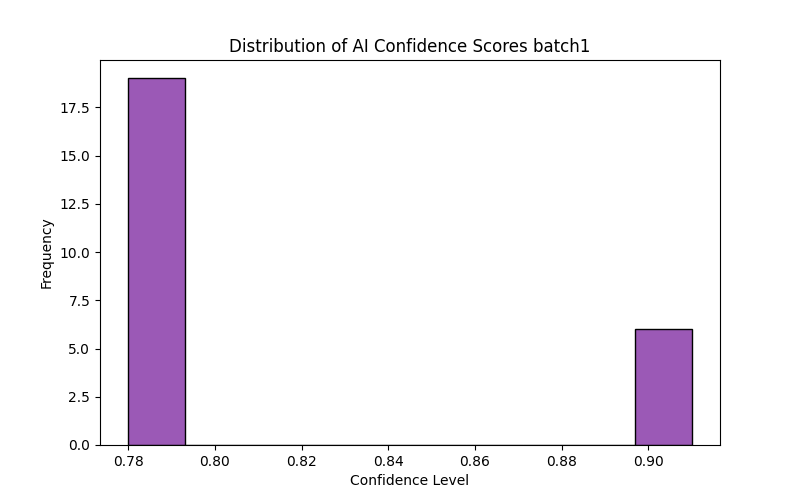

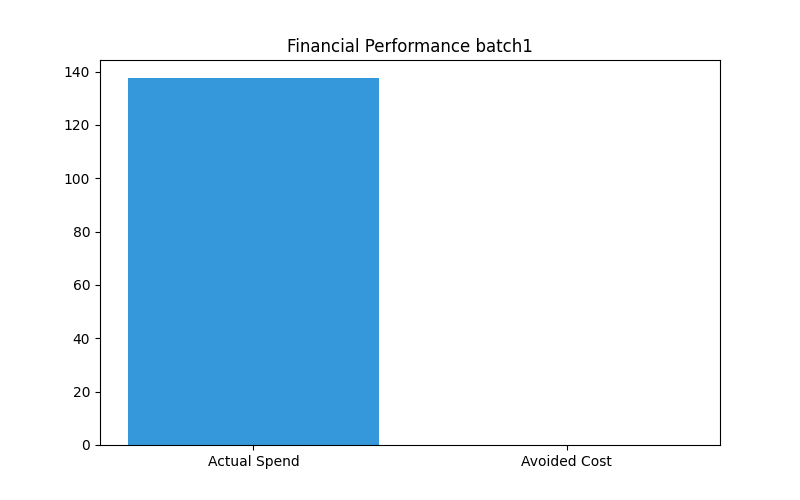

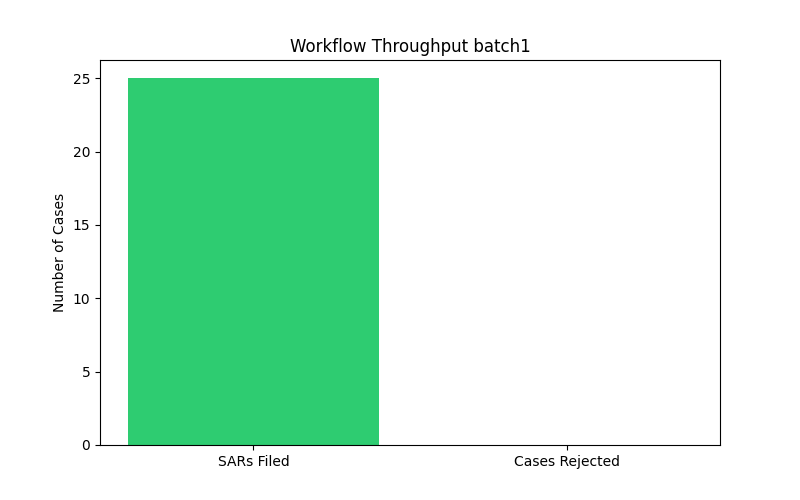


✨ Results for: BATCH2


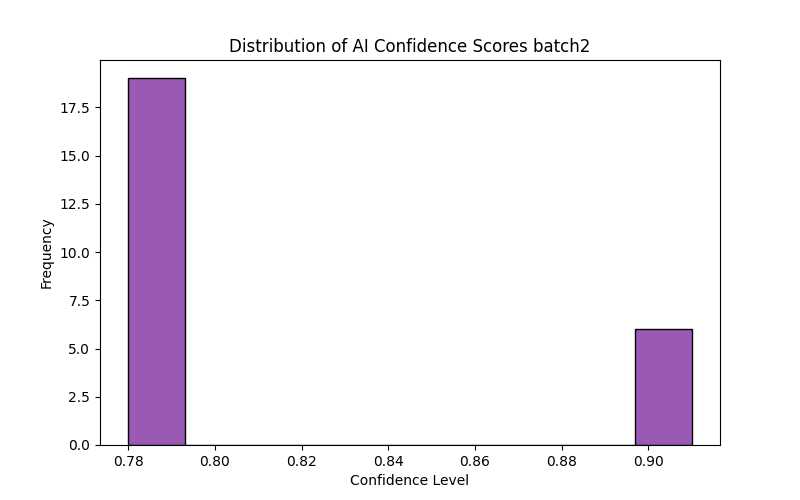

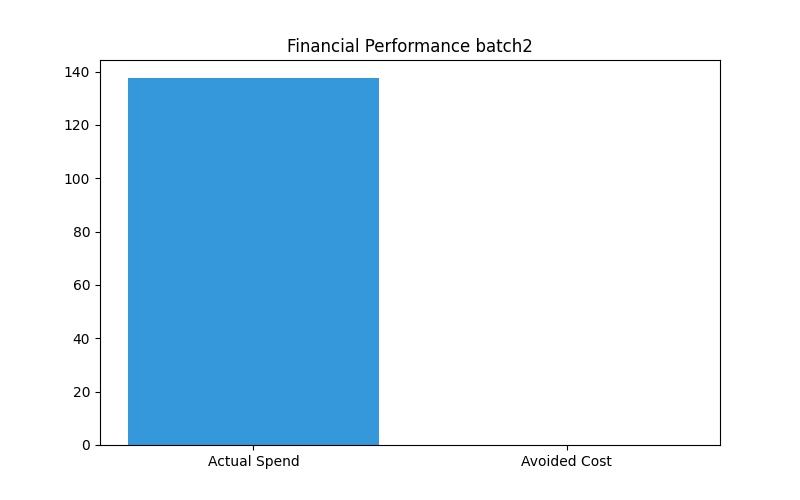

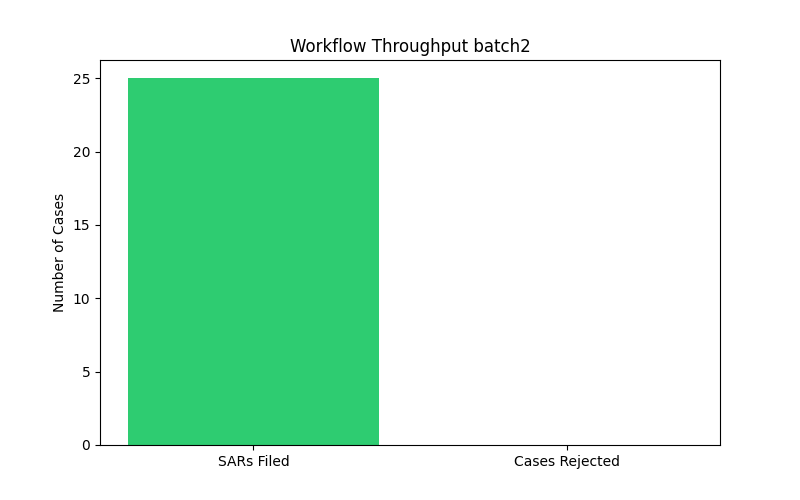

In [14]:
# ── CELL 11 — Display Charts ──────────────────────────────────────────────
print("\n--- 📊 Final Dashboard ---")
 
current_run_files = sorted([
    f for f in os.listdir(OUTPUT_DIR)
    if f.startswith(reporter.timestamp)
])
 
batches_run = sorted(set(
    f.split('_')[-1].replace('.png', '') for f in current_run_files
))
 
for batch in batches_run:
    print(f"\n✨ Results for: {batch.upper()}")
    for file in sorted(f for f in current_run_files if batch in f):
        display(Image(filename=os.path.join(OUTPUT_DIR, file)))
 

In [15]:
# ── CELL 12 — Dashboard Data Sync (payload by batch) ─────────────────────
from demo_integration_pipeline import sync_dashboard_data
 
payload = {
    label_hr: {
        "processed":      processed_cases_hr,
        "approved":       approved_sars_hr,
        "rejected":       rejected_cases_hr,
        "audit_decisions": audit_decisions_hr,
    },
    label_rm: {
        "processed":      processed_cases_rm,
        "approved":       approved_sars_rm,
        "rejected":       rejected_cases_rm,
        "audit_decisions": audit_decisions_rm,
    },
}
 
sync_dashboard_data(payload)
 
# Debug: confirm audit_decisions columns are complete
import pandas as pd
test_df = pd.DataFrame(audit_decisions_hr)
print("\nAudit decision columns:", test_df.columns.tolist())

✅ Data synced → /workspace/cd14685-fin-serv-agentic-c1-classroom/project/starter/outputs/live_dashboard/dashboard_data_sample.json

Audit decision columns: ['case_id', 'customer_id', 'customer_name', 'risk_rating', 'decision', 'ai_classification', 'ai_confidence', 'compliance_narrative_exists']


In [16]:
# ── CELL 13 — Aggregate SAR History → Parquet ────────────────────────────
# Writes to: starter/outputs/live_dashboard/sar_history.parquet
#        and: starter/outputs/live_dashboard/sar_history_meta.json
from demo_integration_pipeline import aggregate_sar_history
 
df_history = aggregate_sar_history(config)
 
 
# ── CELL 14 — Build Enriched Case Records & Export Live Session ───────────
# Writes to: starter/outputs/live_dashboard/live_session.json
from demo_integration_pipeline import build_all_case_records, export_live_session
 
all_cases = build_all_case_records(
    selected_customers,
    rest_of_cases,
    audit_decisions,
    approved_sars,
    rejected_cases,
)
 
export_live_session(all_cases, approved_sars, rejected_cases)
 
print("\n✅ All exports complete.")
print("   To view the dashboard:")
print("   cd starter && streamlit run app.py")

Loaded 1565 / 1568 files.  Failures: 3
Sample failures: [('SAR_11b6e035.json', 'Expecting value: line 1 column 1 (char 0)'), ('SAR_45c00082.json', 'Expecting value: line 1 column 1 (char 0)'), ('SAR_ca4a2210.json', 'Expecting value: line 1 column 1 (char 0)')]

--- classification value_counts ---
classification
Other               1111
Money_Laundering     268
Structuring          103
High Risk             83
Name: count, dtype: int64

--- risk_level value_counts ---
risk_level
High        1202
Critical     268
Level 3       83
Medium        12
Name: count, dtype: int64

--- review_status value_counts ---
review_status
human_approved    1565
Name: count, dtype: int64

--- compliance_status value_counts ---
compliance_status
approved    1565
Name: count, dtype: int64

--- risk_rating value_counts ---
risk_rating
Medium    1194
High       371
Name: count, dtype: int64

--- human_reviewer value_counts ---
human_reviewer
compliance_officer    1565
Name: count, dtype: int64

--- ai_generate